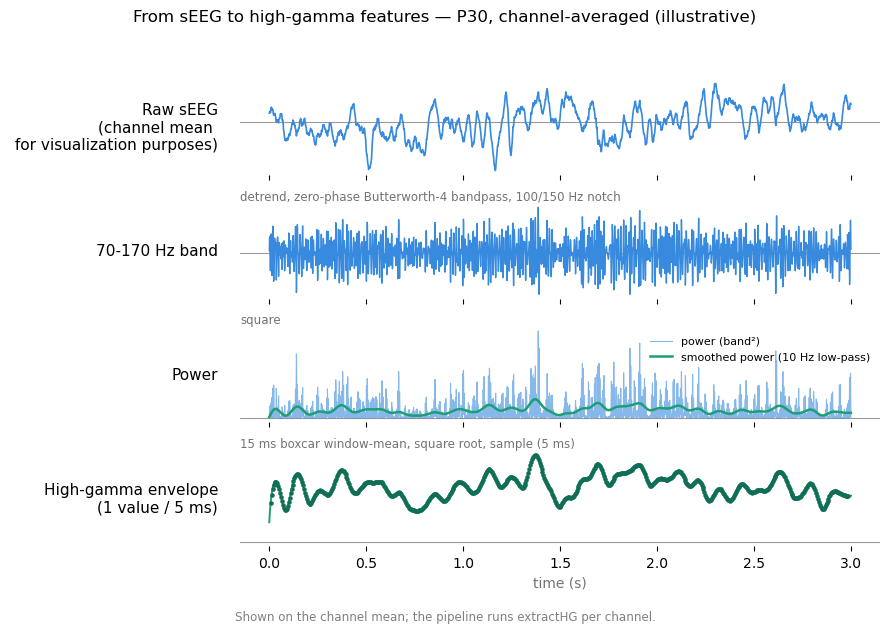

In [12]:
import numpy as np, os
import scipy.signal as sps
import matplotlib.pyplot as plt
from config import DUTCH_30_PATH

pid, EEG_SR = 'P30', 1024
raw = np.load(os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_sEEG.npy'))   # (samples, channels)

# --- grab a real sentence window (uses pipeline if loaded; else a fixed window)
try:
    wd = pipeline.split_result['word_segments_dict'][pid]
    sents = [s for s in wd['sentence_list'] if (s.get('text') if isinstance(s, dict) else s)]
    s = sents[5]
    a, b = int(s['stim_start_idx']), int(s['stim_end_idx'])
except Exception:
    a = int(60 * EEG_SR); b = a + int(3 * EEG_SR)

x0 = raw[a:b].mean(axis=1)                 # ---- CHANNEL MEAN (all electrodes) ----
t  = np.arange(len(x0)) / EEG_SR

# --- extractHG steps, capturing intermediates -------------------------------
def sos(order, f, btype):
    return sps.iirfilter(order, np.asarray(f, float) / (EEG_SR / 2),
                         btype=btype, output='sos')
xd   = sps.detrend(x0)
xb   = sps.sosfiltfilt(sos(4, [70, 170], 'bandpass'), xd)
xb   = sps.sosfiltfilt(sos(4, [98, 102], 'bandstop'), xb)
band = sps.sosfiltfilt(sos(4, [148, 152], 'bandstop'), xb)   # 70-170 Hz band (zero-phase)
power = band ** 2                                             # square
lp    = np.abs(sps.sosfiltfilt(sos(4, 10, 'lowpass'), power))  # 10 Hz low-pass -> smoothed power

win, hop = int(round(0.015*EEG_SR)), int(round(0.005*EEG_SR))   # 15 ms boxcar, 5 ms shift
nw = int(np.floor((len(lp) - win) / hop))
samp_t = np.array([(w*hop + win/2)/EEG_SR for w in range(nw)])
samp_v = np.sqrt(np.array([lp[w*hop:w*hop+win].mean() for w in range(nw)]))  # boxcar mean -> sqrt
env_cont = np.sqrt(lp)                                          # continuous envelope (amplitude)

# --- plot --------------------------------------------------------------------
BLUE, ENV, ENV_D = "#378ADD", "#1D9E75", "#0F6E56"
fig, ax = plt.subplots(4, 1, figsize=(9, 6.2), sharex=True)

ax[0].plot(t, x0, color=BLUE, lw=1.2); ax[0].axhline(x0.mean(), color="0.6", lw=0.8, zorder=0)
ax[0].set_ylabel("Raw sEEG\n(channel mean \n for visualization purposes)", rotation=0, ha="right", va="center", fontsize=11, labelpad=16)

ax[1].plot(t, band, color=BLUE, lw=1.0); ax[1].axhline(0, color="0.6", lw=0.8, zorder=0)
ax[1].set_ylabel("70-170 Hz band", rotation=0, ha="right", va="center", fontsize=11, labelpad=16)
ax[1].set_title("detrend, zero-phase Butterworth-4 bandpass, 100/150 Hz notch",
                fontsize=8.5, color="0.45", loc="left", pad=2)

ax[2].plot(t, power, color=BLUE, lw=0.8, alpha=0.6, label="power (band²)")
ax[2].plot(t, lp, color=ENV, lw=1.8, label="smoothed power (10 Hz low-pass)")
ax[2].set_ylim(0, np.percentile(power, 99.5))   # clip a few extreme spikes
ax[2].axhline(0, color="0.6", lw=0.8, zorder=0)
ax[2].set_ylabel("Power", rotation=0, ha="right", va="center", fontsize=11, labelpad=16)
ax[2].set_title("square", fontsize=8.5, color="0.45", loc="left", pad=2)
ax[2].legend(fontsize=8, loc="upper right", frameon=False)

ax[3].plot(t, env_cont, color=ENV, lw=1.4)                                    # same colour as overlay
ax[3].plot(samp_t, samp_v, ".", color=ENV_D, ms=4.5, zorder=3)
ax[3].axhline(0, color="0.6", lw=0.8, zorder=0)
ax[3].set_ylabel("High-gamma envelope\n(1 value / 5 ms)", rotation=0, ha="right", va="center",
                 fontsize=11, labelpad=16)
ax[3].set_title("15 ms boxcar window-mean, square root, sample (5 ms)",
                fontsize=8.5, color="0.45", loc="left", pad=2)
ax[3].set_xlabel("time (s)", fontsize=10, color="0.45")

for a_ in ax:
    a_.set_yticks([]); [sp.set_visible(False) for sp in a_.spines.values()]

fig.suptitle(f"From sEEG to high-gamma features — {pid}, channel-averaged (illustrative)",
             fontsize=12, y=0.99)
fig.text(0.5, 0.005, "Shown on the channel mean; the pipeline runs extractHG per channel.",
         ha="center", fontsize=8.5, color="0.5")
fig.tight_layout(rect=[0.0, 0.03, 1.0, 0.95])
fig.savefig("hg_extraction_real.png", dpi=200, bbox_inches="tight")
plt.show()

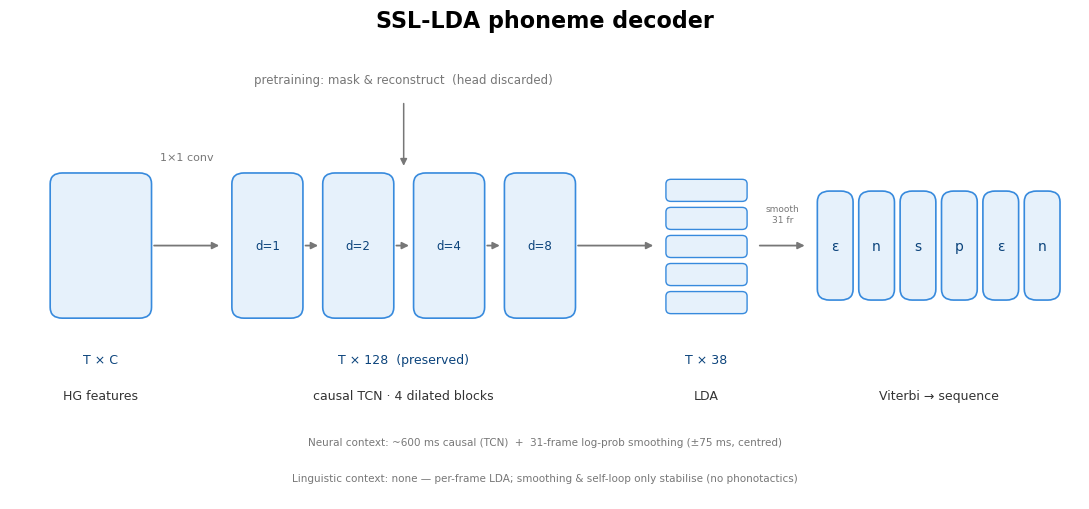

In [34]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

FILL, EDGE, INK = "#E6F1FB", "#378ADD", "#0C447C"   # blue fill / edge / dark-blue text
GREY = "#777"

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.set_xlim(0, 106); ax.set_ylim(0, 50); ax.axis("off")

ax.set_title("SSL-LDA phoneme decoder", fontsize=16, fontweight="bold",
             color="black", pad=14)

def box(x, y, w, h, inner=None, fs=9, lw=1.2, rs=1.2):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
        boxstyle=f"round,pad=0.02,rounding_size={rs}",
        linewidth=lw, edgecolor=EDGE, facecolor=FILL))
    if inner:
        ax.text(x + w/2, y + h/2, inner, ha="center", va="center", fontsize=fs, color=INK)

def arrow(x1, x2, y=28):
    ax.annotate("", xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle="-|>", color=GREY, lw=1.3))

# input
box(4, 20, 10, 16)
# four dilated TCN blocks (all same shape -> same size)
for x, d in [(22, "d=1"), (31, "d=2"), (40, "d=4"), (49, "d=8")]:
    box(x, 20, 7, 16, inner=d, fs=8.5)
# LDA -> column of per-frame posterior cells
lda_x, lda_w = 65, 8
for i in range(5):
    box(lda_x, 20.5 + i * 3.1, lda_w, 2.4, lw=1.0, rs=0.5)
# Viterbi output tokens
for x, p in zip([80, 84.1, 88.2, 92.3, 96.4, 100.5], ["ɛ", "n", "s", "p", "ɛ", "n"]):
    box(x, 22, 3.5, 12, inner=p, fs=10)

# arrows
arrow(14, 21)
arrow(29, 30.8); arrow(38, 39.8); arrow(47, 48.8)   # between TCN blocks
arrow(56, 64)                                         # TCN -> LDA  (embedding)
arrow(74, 79)                                         # LDA -> Viterbi
ax.text(17.5, 37.5, "1×1 conv", ha="center", fontsize=8, color=GREY)
# log-prob smoothing between LDA and Viterbi
ax.text(76.5, 31.5, "smooth\n31 fr", ha="center", va="center", fontsize=6.5, color=GREY)

# dimension labels
ax.text(9,  15, "T × C", ha="center", fontsize=9, color=INK)
ax.text(39, 15, "T × 128  (preserved)", ha="center", fontsize=9, color=INK)
ax.text(69, 15, "T × 38", ha="center", fontsize=9, color=INK)

# names
for cx, name in [(9, "HG features"), (39, "causal TCN · 4 dilated blocks"),
                 (69, "LDA"), (92, "Viterbi → sequence")]:
    ax.text(cx, 11, name, ha="center", fontsize=9, color="#333")

# pretraining note — plain text, NO box — with an arrow into the TCN
ax.text(39, 46, "pretraining: mask & reconstruct  (head discarded)",
        ha="center", fontsize=8.5, color=GREY)
ax.annotate("", xy=(39, 36.5), xytext=(39, 44),
            arrowprops=dict(arrowstyle="-|>", color=GREY, lw=1.1))

# receptive-field footer
ax.text(53, 6,
        "Neural context: ~600 ms causal (TCN)  +  31-frame log-prob smoothing (±75 ms, centred)",
        ha="center", fontsize=7.5, color=GREY)
ax.text(53, 2,
        "Linguistic context: none — per-frame LDA; smoothing & self-loop only stabilise (no phonotactics)",
        ha="center", fontsize=7.5, color=GREY)

fig.tight_layout()
fig.savefig("ssl_tcn_dimensions.png", dpi=200, bbox_inches="tight")   # transparent=True for dark slides
plt.show()

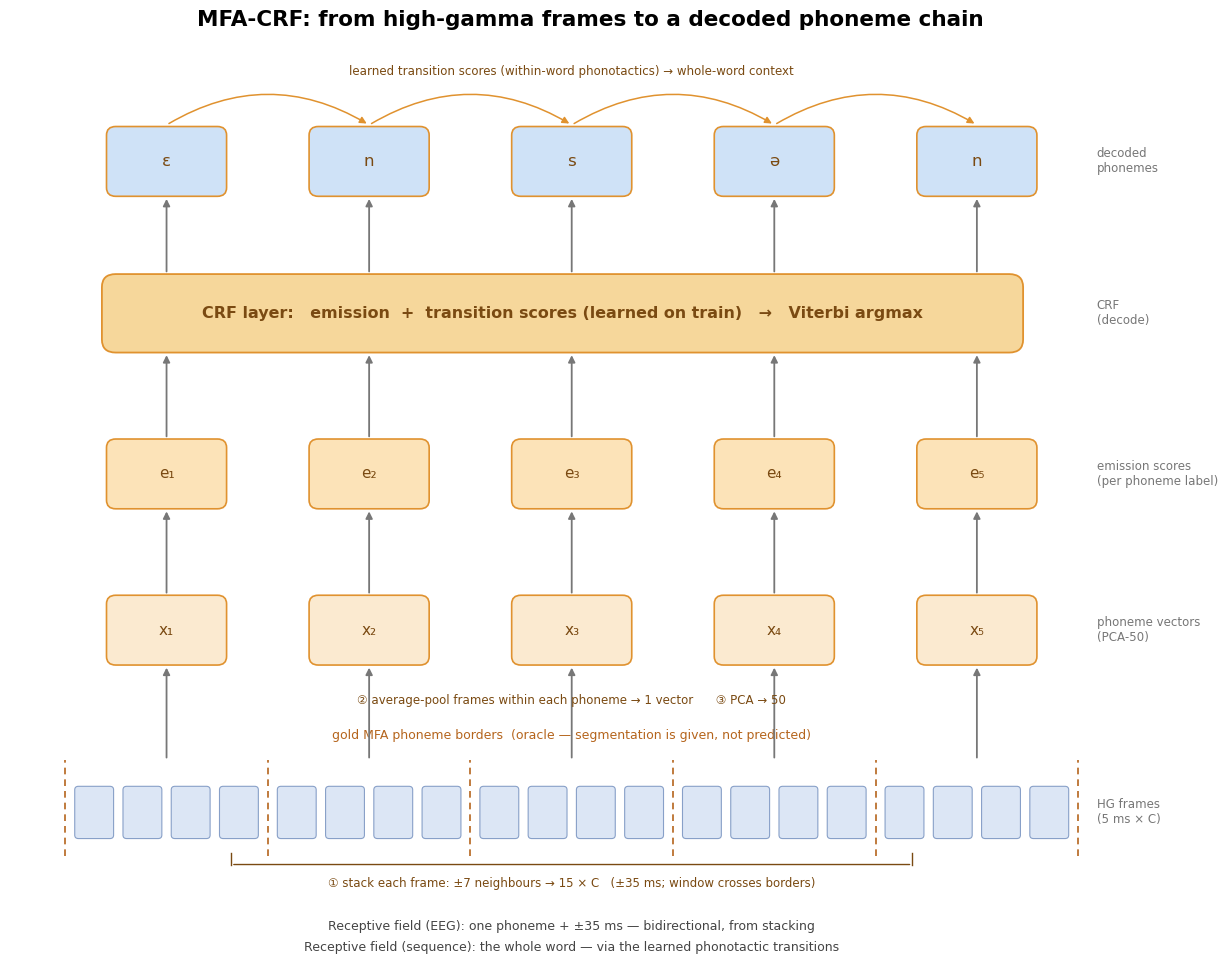

In [31]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

A_FILL, A_EDGE, A_INK = "#FBEAD0", "#E0922F", "#7A4A12"   # amber
FRM    = "#DCE6F5"; E_FILL = "#FCE3B8"; BAR = "#F6D79B"; OUT = "#CFE2F7"
GREY = "#777"; DASH = "#B5651D"

fig, ax = plt.subplots(figsize=(12.5, 9.8))
ax.set_xlim(0, 126); ax.set_ylim(-6, 100); ax.axis("off")          # +RF: room for footer
ax.set_title("MFA-CRF: from high-gamma frames to a decoded phoneme chain",
             fontsize=15.5, fontweight="bold", color="black", pad=10)

def cell(cx, y, text, w=13, h=8, fill=A_FILL, fs=11):
    ax.add_patch(FancyBboxPatch((cx - w/2, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=1.0",
        linewidth=1.2, edgecolor=A_EDGE, facecolor=fill))
    ax.text(cx, y + h/2, text, ha="center", va="center", fontsize=fs, color=A_INK)

def varrow(cx, y1, y2, color=GREY):
    ax.annotate("", xy=(cx, y2), xytext=(cx, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=1.3))

cols = [17, 39, 61, 83, 105]; seg_bounds = [6, 28, 50, 72, 94, 116]
feat = ["x₁","x₂","x₃","x₄","x₅"]; emit = ["e₁","e₂","e₃","e₄","e₅"]; tags = ["ɛ","n","s","ə","n"]

for i in range(5):
    L, R = seg_bounds[i], seg_bounds[i+1]; nfr, fw = 4, 4.2
    gap = (R - L - nfr*fw) / (nfr + 1)
    for k in range(nfr):
        fx = L + gap*(k+1) + fw*k
        ax.add_patch(FancyBboxPatch((fx, 8), fw, 6, boxstyle="round,pad=0.01,rounding_size=0.4",
            linewidth=0.8, edgecolor="#88A0C8", facecolor=FRM))
for b in seg_bounds:
    ax.plot([b, b], [6, 17], ls=(0, (4, 3)), lw=1.2, color=DASH)
ax.text(61, 19.5, "gold MFA phoneme borders  (oracle — segmentation is given, not predicted)",
        ha="center", fontsize=9, color=DASH)
ax.text(118, 11, "HG frames\n(5 ms × C)", ha="left", va="center", fontsize=8.5, color=GREY)

ax.annotate("", xy=(98, 5), xytext=(24, 5), arrowprops=dict(arrowstyle="-", color=A_INK, lw=1.0))
for xx in (24, 98): ax.plot([xx, xx], [5, 6.3], lw=1.0, color=A_INK)
ax.text(61, 2.4, "① stack each frame: ±7 neighbours → 15 × C   (±35 ms; window crosses borders)",  # +RF: ±35 ms
        ha="center", fontsize=8.5, color=A_INK)

for cx in cols: varrow(cx, 17, 28)
ax.text(61, 23.5, "② average-pool frames within each phoneme → 1 vector      ③ PCA → 50",
        ha="center", fontsize=8.5, color=A_INK)
for cx, t in zip(cols, feat): cell(cx, 28, t)
ax.text(118, 32, "phoneme vectors\n(PCA-50)", ha="left", va="center", fontsize=8.5, color=GREY)

for cx in cols: varrow(cx, 36, 46)
for cx, t in zip(cols, emit): cell(cx, 46, t, fill=E_FILL)
ax.text(118, 50, "emission scores\n(per phoneme label)", ha="left", va="center", fontsize=8.5, color=GREY)

for cx in cols: varrow(cx, 54, 64)
ax.add_patch(FancyBboxPatch((10, 64), 100, 9, boxstyle="round,pad=0.02,rounding_size=1.5",
    linewidth=1.3, edgecolor=A_EDGE, facecolor=BAR))
ax.text(60, 68.5, "CRF layer:   emission  +  transition scores (learned on train)   →   Viterbi argmax",
        ha="center", va="center", fontsize=11.5, fontweight="bold", color=A_INK)
ax.text(118, 68.5, "CRF\n(decode)", ha="left", va="center", fontsize=8.5, color=GREY)

for cx in cols: varrow(cx, 73, 82)
for cx, t in zip(cols, tags): cell(cx, 82, t, fill=OUT, fs=12)
ax.text(118, 86, "decoded\nphonemes", ha="left", va="center", fontsize=8.5, color=GREY)
for x1, x2 in zip(cols[:-1], cols[1:]):
    ax.annotate("", xy=(x2, 90.2), xytext=(x1, 90.2),
                arrowprops=dict(arrowstyle="-|>", color=A_EDGE, lw=1.1, connectionstyle="arc3,rad=-0.3"))
ax.text(61, 96, "learned transition scores (within-word phonotactics) → whole-word context",  # +RF: whole word
        ha="center", fontsize=8.5, color=A_INK)

# +RF: parallel receptive-field footer
ax.text(61, -2.5, "Receptive field (EEG): one phoneme + ±35 ms — bidirectional, from stacking",
        ha="center", fontsize=9, color="#444")
ax.text(61, -5.0, "Receptive field (sequence): the whole word — via the learned phonotactic transitions",
        ha="center", fontsize=9, color="#444")

fig.tight_layout()
fig.savefig("mfa_crf_full.png", dpi=200, bbox_inches="tight")
plt.show()

In [26]:
import numpy as np, pickle
from collections import Counter, defaultdict
from phon_helpers import gather_sequences, needleman_wunsch

ssl = pickle.load(open('results/ssl_results.pkl', 'rb'))   # default-split file (just copied in)
pids = sorted(ssl); rng = np.random.default_rng(0); R = 300

# OLD method: cohort bigram from TEST gold — this is what produced the report
trans = defaultdict(Counter); init = Counter(); uni = Counter()
for pid in pids:
    gb, _ = gather_sequences(ssl[pid])
    for g in gb.values():
        if not g: continue
        init[g[0]] += 1
        for a in g: uni[a] += 1
        for a, b in zip(g[:-1], g[1:]): trans[a][b] += 1
def _d(c): k=list(c); p=np.array([c[x] for x in k],float); return k, p/p.sum()
ik,ip=_d(init); uk,up=_d(uni); td={a:_d(c) for a,c in trans.items()}
def gen(L):
    if L<=0: return []
    s=[rng.choice(ik,p=ip)]
    for _ in range(L-1):
        k,p=td.get(s[-1],(uk,up)); s.append(rng.choice(k,p=p))
    return s
def score_nw(gb,pb):
    m=ng=0
    for sid in gb:
        g=gb[sid]; p=pb.get(sid,[]); ng+=len(g)
        for a,b in needleman_wunsch(g,p):
            if a is not None and b is not None and a==b: m+=1
    return m/max(ng,1)
rows=[]
for pid in pids:
    gb,pb=gather_sequences(ssl[pid]); rm=score_nw(gb,pb)
    bm=[score_nw(gb,{sid:gen(len(pb.get(sid,[]))) for sid in gb}) for _ in range(R)]
    rows.append((pid,rm,float(np.mean(bm))))
    print(f"{pid} SSL {rm:.3f} bigram {np.mean(bm):.3f}")
A=np.array([(r[1],r[2]) for r in rows]); d=A[:,0]-A[:,1]
from scipy.stats import ttest_rel, wilcoxon
print(f"MEAN SSL {A[:,0].mean():.3f} bigram {A[:,1].mean():.3f}  d {d.mean():+.3f}  "
      f"SSL>big {(d>0).sum()}/{len(d)}  t p={ttest_rel(A[:,0],A[:,1]).pvalue:.4g}")

P21 SSL 0.348 bigram 0.309
P22 SSL 0.309 bigram 0.288
P23 SSL 0.360 bigram 0.357
P24 SSL 0.379 bigram 0.359
P25 SSL 0.337 bigram 0.305
P26 SSL 0.372 bigram 0.332
P27 SSL 0.350 bigram 0.339
P28 SSL 0.320 bigram 0.323
P29 SSL 0.312 bigram 0.292
P30 SSL 0.358 bigram 0.380
MEAN SSL 0.345 bigram 0.328  d +0.016  SSL>big 8/10  t p=0.02526


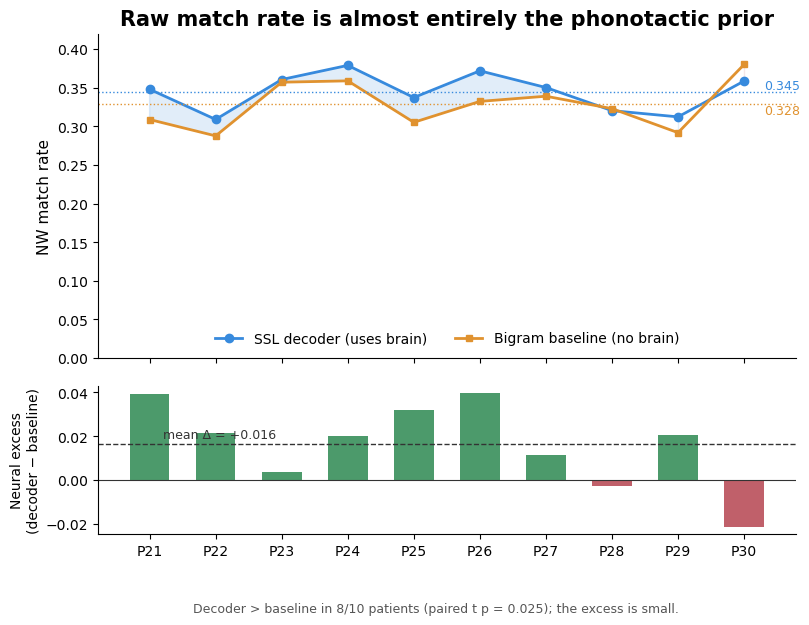

In [30]:
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon

# --- adapt `rows` -> arrays ---
pats  = [r[0] for r in rows]
dec   = np.array([r[1] for r in rows])     # SSL decoder match
base  = np.array([r[2] for r in rows])     # bigram baseline match
#   NOTE: if `rows` came from the 5-tuple block (pid, ssl, ssl_n3, big, big_n3),
#   use r[3] instead of r[2] for `base`.
delta = dec - base
p_t   = ttest_rel(dec, base).pvalue
n_pos = int((delta > 0).sum())
x = np.arange(len(pats))

BLUE, AMBER, POS, NEG = "#378ADD", "#E0922F", "#4C9A6B", "#C0606A"
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True,
                               gridspec_kw=dict(height_ratios=[2.2, 1], hspace=0.12))

ax1.fill_between(x, base, dec, where=dec >= base, color=BLUE, alpha=0.15)
ax1.fill_between(x, base, dec, where=dec <  base, color=NEG,  alpha=0.15)
ax1.plot(x, dec,  "-o", color=BLUE,  lw=2, ms=6, label="SSL decoder (uses brain)")
ax1.plot(x, base, "-s", color=AMBER, lw=2, ms=5, label="Bigram baseline (no brain)")
ax1.axhline(dec.mean(),  ls=":", color=BLUE,  lw=1)
ax1.axhline(base.mean(), ls=":", color=AMBER, lw=1)
ax1.text(len(pats)-0.7, dec.mean(),  f"{dec.mean():.3f}",  color=BLUE,  va="bottom", fontsize=9)
ax1.text(len(pats)-0.7, base.mean(), f"{base.mean():.3f}", color=AMBER, va="top",    fontsize=9)
ax1.set_ylim(0, 0.42); ax1.set_ylabel("NW match rate", fontsize=11)
ax1.legend(frameon=False, loc="lower center", ncol=2, fontsize=10)
ax1.set_title("Raw match rate is almost entirely the phonotactic prior",
              fontsize=15, fontweight="bold")
ax1.spines[["top", "right"]].set_visible(False)

ax2.bar(x, delta, color=[POS if d >= 0 else NEG for d in delta], width=0.6)
ax2.axhline(0, color="#333", lw=0.8)
ax2.axhline(delta.mean(), ls="--", color="#333", lw=1)
ax2.text(0.2, delta.mean() + 0.003, f"mean Δ = {delta.mean():+.3f}", fontsize=9, color="#333")
ax2.set_ylabel("Neural excess\n(decoder − baseline)", fontsize=10)
ax2.set_xticks(x); ax2.set_xticklabels(pats)
ax2.spines[["top", "right"]].set_visible(False)

fig.text(0.5, -0.01,
         f"Decoder > baseline in {n_pos}/{len(delta)} patients (paired t p = {p_t:.2g}); "
         f"the excess is small.",
         ha="center", fontsize=9, color="#555")
fig.savefig("match_vs_prior.png", dpi=200, bbox_inches="tight")
plt.show()

loaded results/ssl_shift_perm_crfsplit.pkl
loaded results/crf_shift_perm.pkl


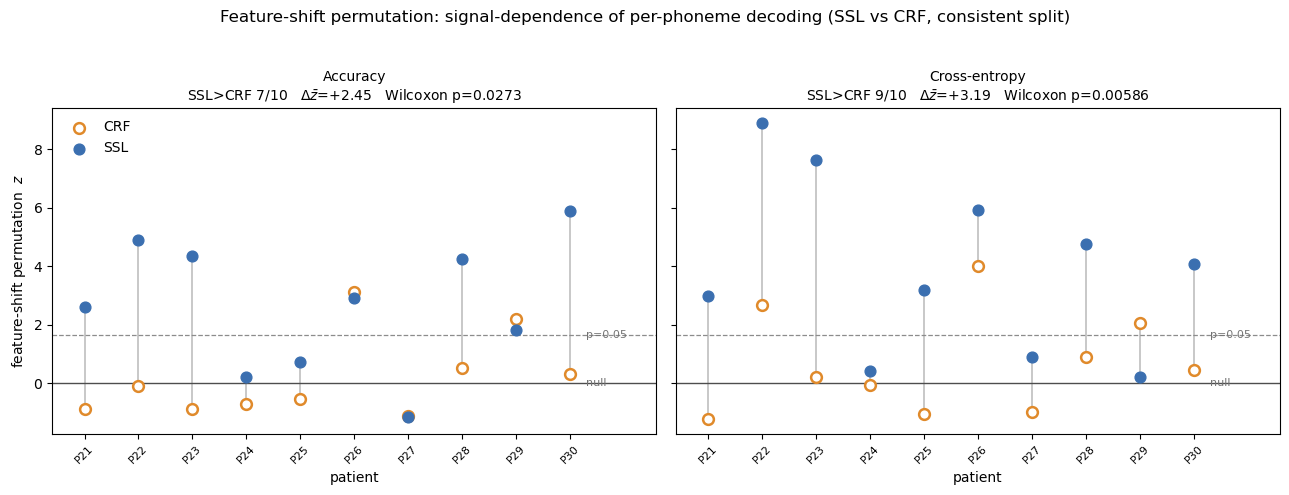

In [29]:
import os, pickle, numpy as np, scipy.stats as ss, matplotlib.pyplot as plt

def _load(name):
    for p in [f'results/{name}',
              rf'C:\mozg\code\SingleWordProductionDutch_step2\results\{name}']:
        if os.path.exists(p):
            print('loaded', p); return pickle.load(open(p, 'rb'))
    raise FileNotFoundError(name + ' — run the permutation save cells first (SSL + MFA_CRF)')

ssl_crf = _load('ssl_shift_perm_crfsplit.pkl')
crf     = _load('crf_shift_perm.pkl')

metrics = [('acc_pho', 'Accuracy'), ('ce_pho', 'Cross-entropy')]
pids = sorted(set(ssl_crf['acc_pho']) & set(crf['acc_pho']))
x = np.arange(len(pids))
SSL_C, CRF_C = '#3b6fb0', '#e08a2b'

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (mkey, mlab) in zip(axes, metrics):
    sz = np.array([ssl_crf[mkey][p]['z'] for p in pids])
    cz = np.array([crf[mkey][p]['z']     for p in pids])
    for xi, a, b in zip(x, sz, cz):
        ax.plot([xi, xi], [b, a], color='0.75', lw=1.2, zorder=1)
    ax.scatter(x, cz, s=60, facecolors='white', edgecolors=CRF_C, linewidths=1.8, label='CRF', zorder=3)
    ax.scatter(x, sz, s=60, color=SSL_C, label='SSL', zorder=3)
    ax.axhline(0, color='0.3', lw=1.0); ax.axhline(1.64, color='0.55', ls='--', lw=0.9)
    ax.text(x[-1] + 0.3, 1.64, 'p=0.05', va='center', ha='left', fontsize=8, color='0.45')
    ax.text(x[-1] + 0.3, 0.0,  'null',   va='center', ha='left', fontsize=8, color='0.45')
    d = sz - cz; w = ss.wilcoxon(sz, cz).pvalue
    ax.set_title(f"{mlab}\nSSL>CRF {int((d>0).sum())}/{len(d)}   "
                 f"$\\Delta\\bar{{z}}$={d.mean():+.2f}   Wilcoxon p={w:.3g}", fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(pids, rotation=45, fontsize=8)
    ax.set_xlabel('patient'); ax.set_xlim(-0.6, len(pids) + 0.6)

axes[0].set_ylabel('feature-shift permutation  $z$')
axes[0].legend(loc='upper left', frameon=False)
fig.suptitle('Feature-shift permutation: signal-dependence of per-phoneme decoding '
             '(SSL vs CRF, consistent split)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig_shift_permutation.png', dpi=200, bbox_inches='tight')
plt.show()